USER_HOME_DIR=C:\Users\Martin
test torque: 7.39 N.m, test flowrate: 0.002028 m3/s


c:\Users\Martin\Active\otp-sizing\otp\pump\analysis.py:129: RuntimeWarning: divide by zero encountered in scalar divide
  specific_speed = rpm * np.sqrt(Q) / (H_total_real)**0.75


IPA intersection: Q 2.165 L/s, mdot 1.701 kg/s, dp 70.90 bar, H 920.6 m, N 32.96 krpm


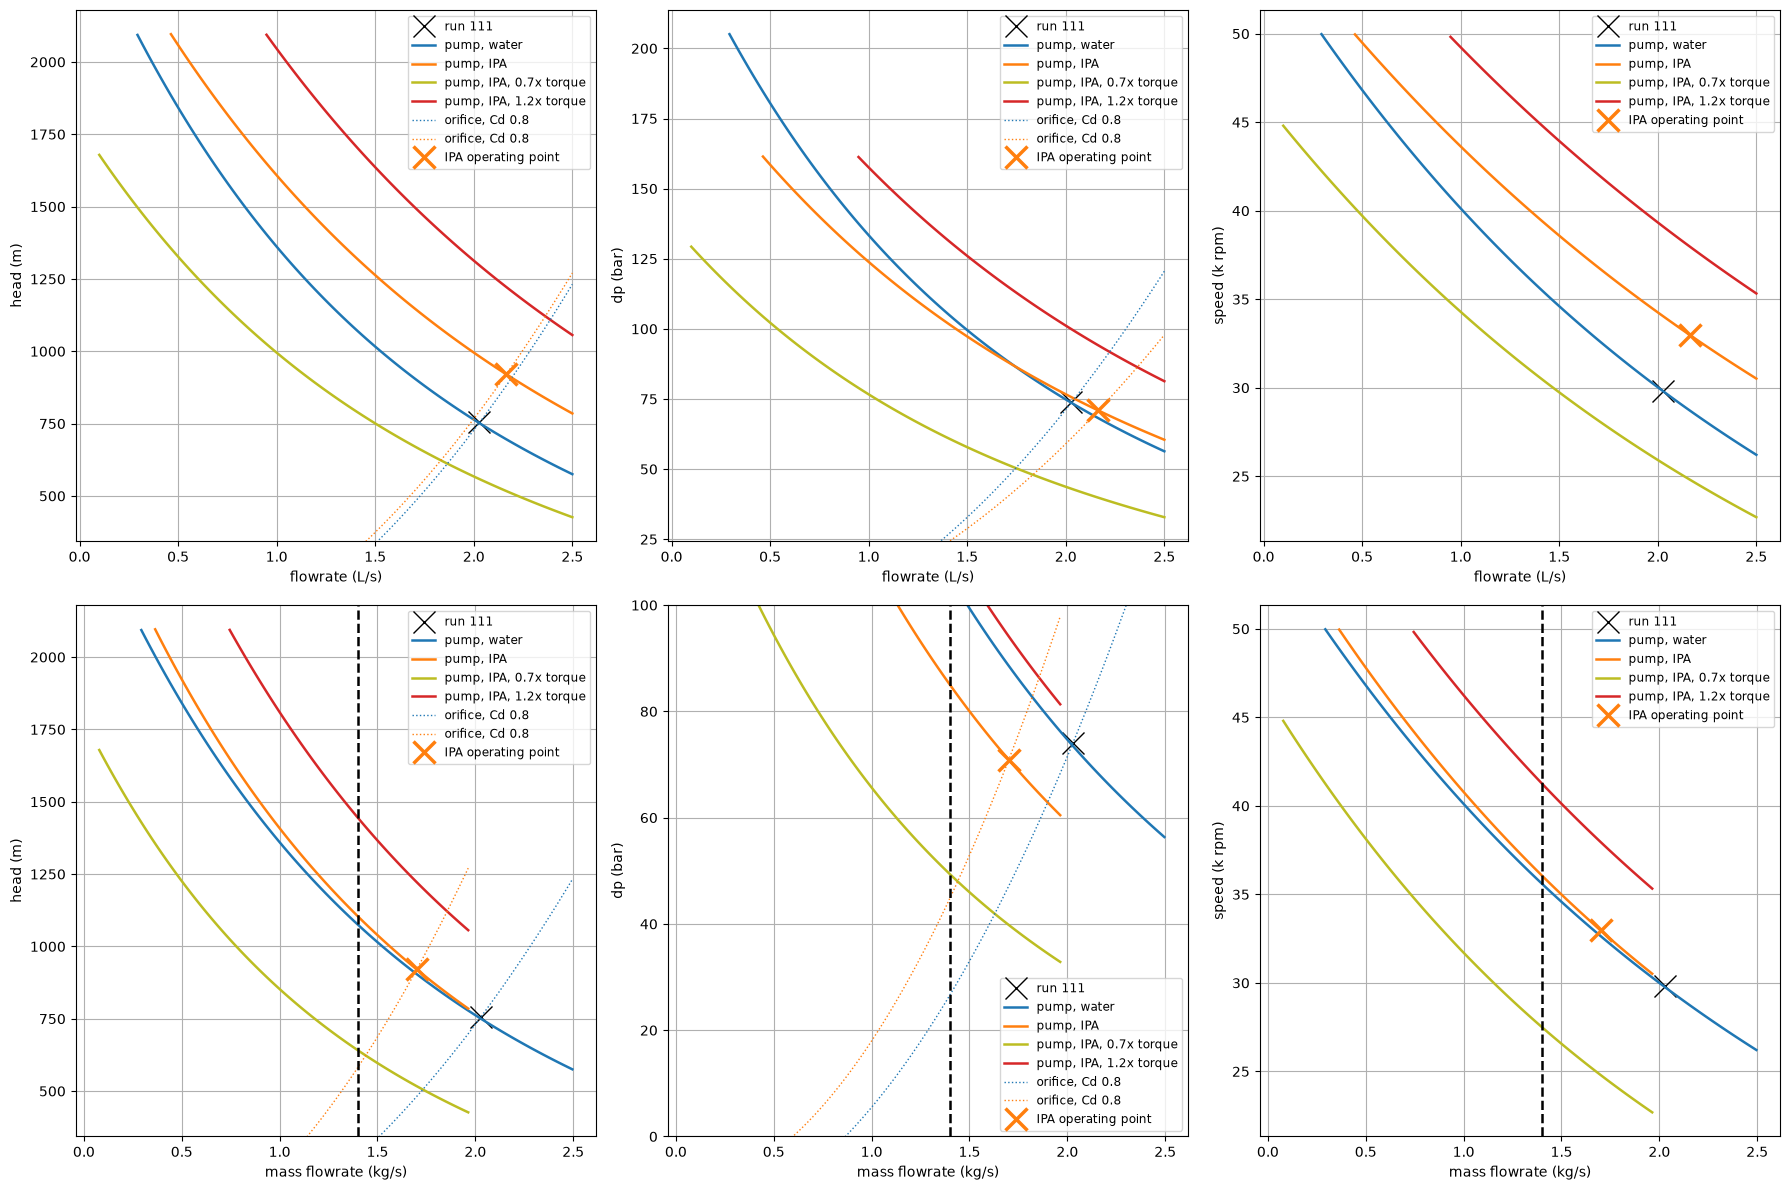

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

TESTBED = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TESTBED))

import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
from pyfluids import FluidsList, Input
from otp.propellants.propellant import Propellant
from otp.pump.analysis import Pump
from otp.pump.records import PumpChoices, PumpGeometry, PumpRequirements
from otp.turbine.analysis import Turbine
from otp.turbine.records import TurbineChoices, TurbineGeometry, TurbineInletGas, TurbineRequirements
from otp.core.units import K_TO_C, g, BAR

T_K, P_IN, P_AMB = 293.15, 17.52 * BAR, 1.01325 * BAR  #K, bar, bar
Q_HI = 2.5e-3
N_MEAS = 29800
FLOWRATES = np.linspace(0.1e-3, Q_HI, 100)

GEOM = PumpGeometry(d_inlet=0.0298 / 1.2,
                    d_1=0.0298, 
                    d_2=0.0689,
                    b_1=0.0074,
                    b_2=0.0032,
                    d_throat=0.0062, 
                    d_outlet=0.0115,
                    d_3=0.0, 
                    b_3=0.0, 
                    s_ax=0.0)            # unused
PUMP = Pump(PumpRequirements(None, 1.2e-3, 760.0), PumpChoices(24e3, 6, 1.0), GEOM)

class IPA:                      # CoolProp has no propan-2-ol; 20 C literature values
    class _s: density, kinematic_viscosity, pressure = 785.4, 2.66e-6, 4400.0
    class fluid:
        with_state = staticmethod(lambda *a: IPA._s)   # .pressure only read for p_sat
WATER = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)
# IPA = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)


def head_at_flow_torque(fl, flowrate, torque):
    f = lambda rpm: PUMP.point_performance(fl, flowrate, rpm, P_IN, T_K, "lock").torque - torque
    try:
        solved_rpm = brentq(f, 10000, 50000)
        solved_perf = PUMP.point_performance(fl, flowrate, solved_rpm, P_IN, T_K, "lock")
        return solved_perf.H_total_real, solved_perf.dp, solved_rpm
    except:
        solved_rpm = np.nan
        return np.nan, np.nan, np.nan
    
def rho(fl):
    return fl.fluid.with_state(Input.pressure(1e5), Input.temperature(T_K + K_TO_C)).density

CD = 0.8
D_OR = 0.0049

def pump_torque(n, fl):
    """Torque on the 4 mm orifice line: Q where pump dp drives that flow."""
    A = np.pi / 4 * D_OR ** 2
    f = lambda Q: CD * A * np.sqrt(2 * max(PUMP.point_performance(fl, Q, n, P_IN, T_K, "lock").p_outlet - P_AMB, 0) / rho(fl)) - Q
    solved_Q = brentq(f, 1e-7, Q_HI)
    return PUMP.point_performance(fl, solved_Q, n, P_IN, T_K, "lock").torque, solved_Q

test_torque, solved_Q = pump_torque(N_MEAS, WATER)
print(f"test torque: {test_torque:.2f} N.m, test flowrate: {solved_Q:.6f} m3/s")

CASES = {0: {"fluid": WATER, "color": "tab:blue", "label": "water", "torque_mult": 1.0},
            1: {"fluid": IPA, "color": "tab:orange", "label": "IPA", "torque_mult": 1.0},
            2: {"fluid": IPA, "color": "tab:olive", "label": "IPA, 0.7x torque", "torque_mult": 0.7},
            3: {"fluid": IPA, "color": "tab:red", "label": "IPA, 1.2x torque", "torque_mult": 1.2}}

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
[ax1, ax2, ax3, ax4, ax5, ax6] = axs.flatten()
ax1.plot(solved_Q * 1e3, 756, "kx", ms=16, label="run 111")
ax4.plot(solved_Q * 1e3, 756, "kx", ms=16, label="run 111")
ax2.plot(solved_Q * 1e3, 74, "kx", ms=16, label="run 111")
ax5.plot(solved_Q * 1e3, 74, "kx", ms=16, label="run 111")
ax3.plot(solved_Q * 1e3, N_MEAS / 1e3, "kx", ms=16, label="run 111")
ax6.plot(solved_Q * 1e3, N_MEAS / 1e3, "kx", ms=16, label="run 111")

for case in CASES.values():
    fl, c, label, torque_mult = case["fluid"], case["color"], case["label"], case["torque_mult"]

    perf_array = np.array([head_at_flow_torque(fl, flowrate, test_torque * torque_mult) for flowrate in FLOWRATES])
    head_array = perf_array[:, 0]
    dp_array = perf_array[:, 1]
    rpm_array = perf_array[:, 2]

    ax1.plot(FLOWRATES * 1e3, head_array, c, lw=1.8, label="pump, " + label)
    ax2.plot(FLOWRATES * 1e3, dp_array / BAR, c, lw=1.8, label="pump, " + label)
    ax3.plot(FLOWRATES * 1e3, rpm_array / 1e3, c, lw=1.8, label="pump, " + label)

    ax4.plot(FLOWRATES * rho(fl), head_array, c, lw=1.8, label="pump, " + label)
    ax5.plot(FLOWRATES * rho(fl), dp_array / BAR, c, lw=1.8, label="pump, " + label)
    ax6.plot(FLOWRATES * rho(fl), rpm_array / 1e3, c, lw=1.8, label="pump, " + label)

A_OR = np.pi / 4 * D_OR ** 2
Q_F = np.linspace(FLOWRATES[0], FLOWRATES[-1], 200)
for fl, c, lab in [(WATER, "tab:blue", True), (IPA, "tab:orange", False)]:
# for fl, c, lab in [(IPA, "tab:orange", False)]:
    r = rho(fl)
    for cd, ls in [(0.8, ":")]:
        if fl == IPA:
            dp_or = 0.5 * r * (Q_F / (cd * A_OR)) ** 2 - (11*BAR - P_AMB)      # pump dp this orifice needs at Q
        if fl == WATER:
            dp_or = 0.5 * r * (Q_F / (cd * A_OR)) ** 2 - (P_IN - P_AMB)      # pump dp this orifice needs at Q
        for ax, x, y in [(ax1, Q_F * 1e3, dp_or / (r * g)), (ax2, Q_F * 1e3, dp_or / BAR),
                         (ax4, Q_F * r, dp_or / (r * g)), (ax5, Q_F * r, dp_or / BAR)]:
            lim = ax.get_ylim()
            ax.plot(x, y, c, ls=ls, lw=1, label=f"orifice, Cd {cd}")
            ax.set_ylim(lim)

def pump_orifice_intersection(fl, torque, p_back, cd=CD, Q=FLOWRATES):
    """Q where pump dp (at fixed torque) equals the dp this orifice needs. Returns (Q, H, dp, rpm) or None."""
    dp_or = lambda q: 0.5 * rho(fl) * (q / (cd * A_OR)) ** 2 - (p_back - P_AMB)
    resid = lambda q: head_at_flow_torque(fl, q, torque)[1] - dp_or(q)
    r = np.array([resid(q) for q in Q])
    i = np.flatnonzero(r[:-1] * r[1:] < 0)          # NaNs drop out (comparison is False)
    if not i.size:
        return None
    Q_x = brentq(resid, Q[i[0]], Q[i[0] + 1])
    return (Q_x, *head_at_flow_torque(fl, Q_x, torque))

Q_x, H_x, dp_x, rpm_x = pump_orifice_intersection(IPA, test_torque, 11 * BAR)
m_x = Q_x * rho(IPA)
print(f"IPA intersection: Q {Q_x*1e3:.3f} L/s, mdot {m_x:.3f} kg/s, dp {dp_x/BAR:.2f} bar, H {H_x:.1f} m, N {rpm_x/1e3:.2f} krpm")
for ax, x, y in [(ax1, Q_x * 1e3, H_x), (ax2, Q_x * 1e3, dp_x / BAR), (ax3, Q_x * 1e3, rpm_x / 1e3),
                 (ax4, m_x, H_x), (ax5, m_x, dp_x / BAR), (ax6, m_x, rpm_x / 1e3)]:
    ax.plot(x, y, "x", color="tab:orange", ms=16, mew=2.5, label="IPA operating point")

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.legend(fontsize="small", loc="best")
    ax.grid(True)

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("flowrate (L/s)")

for ax in [ax4, ax5, ax6]:
    ax.set_xlabel("mass flowrate (kg/s)")
    # add vertical line at 1.4
    ax.axvline(1.4, color="k", lw=1.8, ls="--", label="run 111")


ax1.set_ylabel("head (m)")
ax4.set_ylabel("head (m)")
ax2.set_ylabel("dp (bar)")
ax5.set_ylabel("dp (bar)")
ax3.set_ylabel("speed (k rpm)");
ax6.set_ylabel("speed (k rpm)");
ax5.set_ylim(0, 100)

fig.tight_layout(); plt.show()